In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv('../Village_Wise_Data/Bajhedi.csv')

In [3]:
df.head()

,Timestamp,Survey type,Village Name,Household ID (House No.),Name of Head of Household,Gender,Contact Number of Household,Social Category,Total Family Members,Main Occupation,...,Livelihood Schemes [PM Fasal Bima],Livelihood Schemes [Pension Schemes],Awareness about Gram Sabha meetings,Participation in village development,Major village issues,Most urgent need of the village,Suggestions for village development,Enumerator Name,UID,Date
0,01-12-2026 13:22,Baseline,Bajhedi,NaN,Mohan Singh,Male,9.914105e+09,General,4.0,Service,...,Aware,Aware,No,Occasional,"Water, Education, Employment",Road improvements,Making of roads,Hitanshi,25bbl70047,01-12-2026
1,01-12-2026 13:48,Baseline,Bajhedi,NaN,Gurinder kaur,Female,8.872445e+09,General,4.0,Business,...,Not Aware,Not Aware,Yes,Never,"Water, Health, Environment","Transport, Dispensary and pond purification",Regular transport and dispensary,Pushp Ankit kotwal,25bbl70011,01-12-2026
2,01-12-2026 12:52,Baseline,Bajhedi,NaN,Lokesh kumar,Male,9.366641e+08,General,3.0,Business,...,Aware,Aware,Yes,Never,"Water, Health, Environment","Transport, pond should be clean and dispensary",Regular transport and dispensary,Pushp Ankit kotwal,25bbl70011,01-12-2026
3,01-12-2026 12:37,Baseline,Bajhedi,NaN,Nechhater singh,Male,NaN,OBC,6.0,Business,...,Aware,Aware,Yes,Never,"Employment, Environment",Need road,Electricity is required,Ridhi,25bbl70059 25bbl70264,01-12-2026
4,01-12-2026 12:56,Baseline,Bajhedi,NaN,mohan Singh,Male,NaN,OBC,4.0,Labour,...,Not Aware,Not Aware,Yes,Occasional,"Health, Education, Employment, Environment",Need roads,They need access to internet,RIDHII chhayank,25bbl70059 25bbl70264,01-12-2026


In [4]:
df.columns = df.columns.str.strip()
df['Total Family Members'] = pd.to_numeric(df['Total Family Members'], errors='coerce')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 75 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Timestamp                                              84 non-null     object 
 1   Survey type                                            84 non-null     object 
 2   Village Name                                           84 non-null     object 
 3   Household ID (House No.)                               18 non-null     object 
 4   Name of Head of Household                              84 non-null     object 
 5   Gender                                                 84 non-null     object 
 6   Contact Number of Household                            37 non-null     float64
 7   Social Category                                        84 non-null     object 
 8   Total Family Members                                

In [6]:
df.describe()

,Contact Number of Household,Total Family Members,Nutritional issues of children
count,3.700000e+01,84.000000,0.0
mean,8.691624e+09,5.226190,NaN
std,2.164965e+09,2.186217,NaN
min,9.417199e+07,2.000000,NaN
25%,8.054366e+09,4.000000,NaN
50%,9.501385e+09,5.000000,NaN
75%,9.855025e+09,6.000000,NaN
max,9.988878e+09,11.000000,NaN


# Health Inequality Analysis

In [7]:
dist_to_nearest_health_facility = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], 
                                              df['Distance to nearest health facility'], normalize='index') * 100
round(dist_to_nearest_health_facility,2)

Distance to nearest health facility              1-5 km   <1 km   >5 km
Approx. Annual Household Income Social Category                        
1-3 lakh                        General           61.11   16.67   22.22
                                OBC               80.00    0.00   20.00
                                Scheduled Caste   40.00   20.00   40.00
3-5 lakh                        General           57.14   14.29   28.57
                                OBC              100.00    0.00    0.00
                                Scheduled Caste    0.00  100.00    0.00
<1 lakh                         General           52.38   33.33   14.29
                                OBC                0.00    0.00  100.00
                                Scheduled Caste   56.25   31.25   12.50
                                Scheduled Tribe  100.00    0.00    0.00
>5 lakh                         General            0.00   20.00   80.00

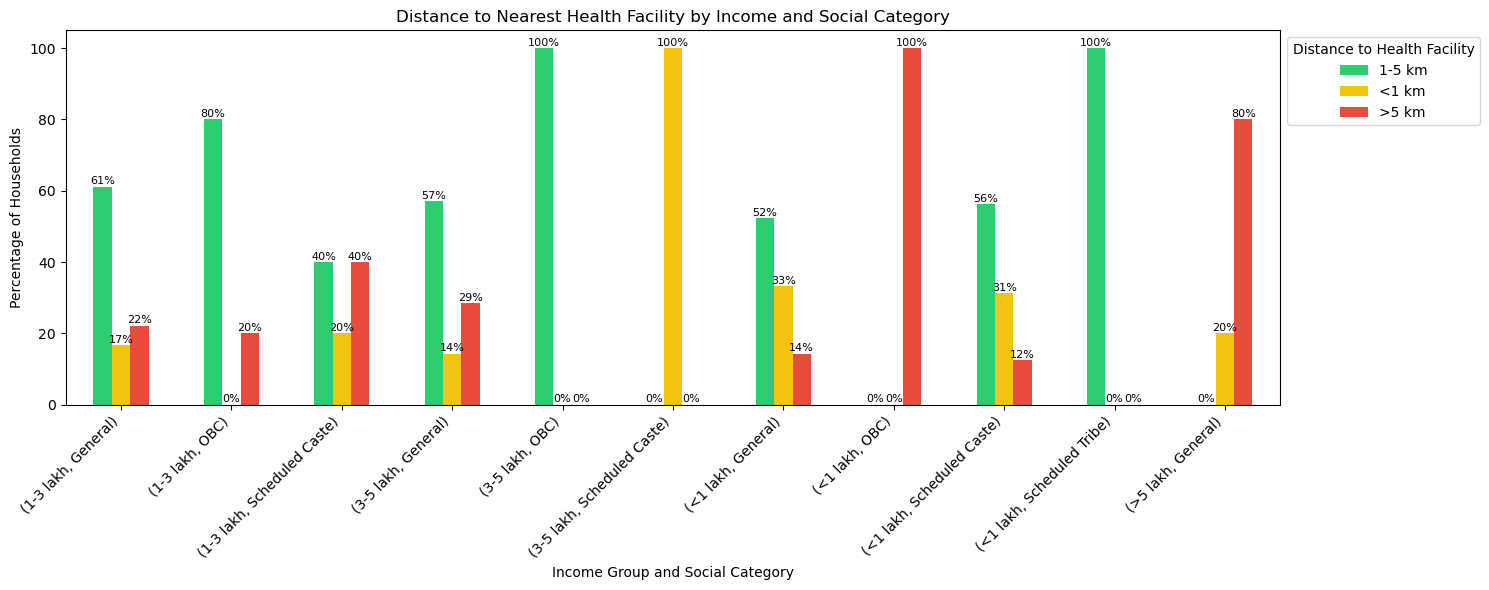

In [8]:
bars = dist_to_nearest_health_facility.plot(
    kind='bar',
    figsize=(15,6),
    color=['#2ECC71','#F1C40F','#E74C3C']
)

# Add percentage labels
for bar in bars.patches:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.0f}%",
        ha='center',
        va='bottom',
        fontsize=8
    )

# Correct titles and labels
plt.title("Distance to Nearest Health Facility by Income and Social Category")
plt.ylabel("Percentage of Households")
plt.xlabel("Income Group and Social Category")

# Improve x-axis readability
plt.xticks(rotation=45, ha='right')

# Correct legend
plt.legend(
    title="Distance to Health Facility",
    labels=["1-5 km", "<1 km", ">5 km"],
    bbox_to_anchor=(1,1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

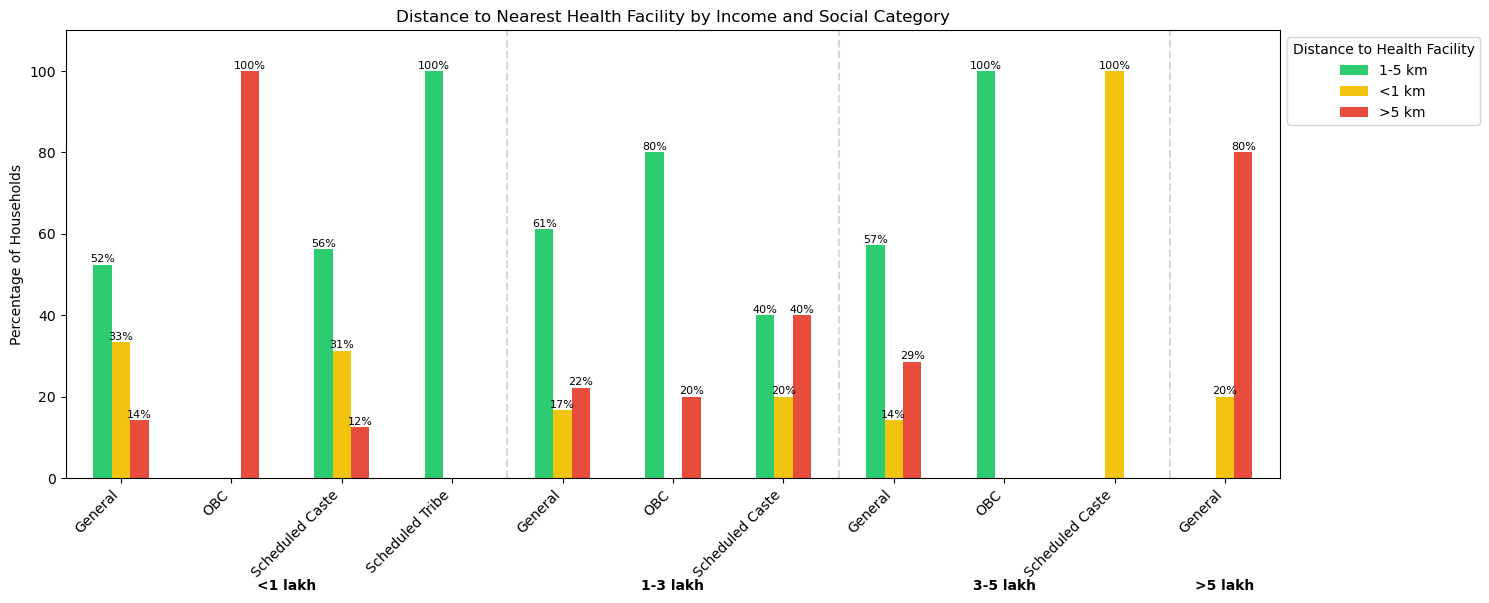

In [9]:
income_order = ['<1 lakh', '1-3 lakh', '3-5 lakh', '>5 lakh']
dist_to_nearest_health_facility = dist_to_nearest_health_facility.reindex(income_order, level=0)
health_plot = dist_to_nearest_health_facility.copy()
health_plot.index = [i[1] for i in health_plot.index]
bars = health_plot.plot(kind='bar', figsize=(15,6), color=['#2ECC71','#F1C40F','#E74C3C'])

income_labels = [i[0] for i in dist_to_nearest_health_facility.index]
positions = []
labels = []
prev = None

for idx, val in enumerate(income_labels):
    if val != prev:
        positions.append(idx)
        labels.append(val)
        prev = val

counts = pd.Series(income_labels).value_counts(sort=False).tolist()
current_pos = 0
for count, label in zip(counts, labels):
    center = current_pos + (count - 1) / 2
    plt.annotate(label, (center, -0.25), xycoords=('data','axes fraction'),
                 ha='center', fontsize=10,fontweight='bold')
    current_pos += count

current_pos = 0
for count in counts[:-1]:
    current_pos += count
    plt.axvline(current_pos - 0.5, color='gray', linestyle='--', alpha=0.3)

for bar in bars.patches:
    if bar.get_height() > 0:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f"{bar.get_height():.0f}%",
            ha='center',
            va='bottom',
            fontsize=8)

plt.title("Distance to Nearest Health Facility by Income and Social Category")
plt.ylabel("Percentage of Households")
plt.legend(title="Distance to Health Facility", bbox_to_anchor=(1,1), loc='upper left')
plt.ylim(0, 110)
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.show()

In [10]:
type_of_facility_used = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], df['Type of facility used'], 
                                   normalize='index') * 100

round(type_of_facility_used,2)

Type of facility used                               PHC  Private  Sub-Centre
Approx. Annual Household Income Social Category                             
1-3 lakh                        General           61.11    33.33        5.56
                                OBC               60.00    20.00       20.00
                                Scheduled Caste   60.00    40.00        0.00
3-5 lakh                        General           28.57    71.43        0.00
                                OBC              100.00     0.00        0.00
                                Scheduled Caste    0.00   100.00        0.00
<1 lakh                         General           61.90    38.10        0.00
                                OBC                0.00    33.33       66.67
                                Scheduled Caste   31.25    68.75        0.00
                                Scheduled Tribe  100.00     0.00        0.00
>5 lakh                         General           20.00    80.00        0.00

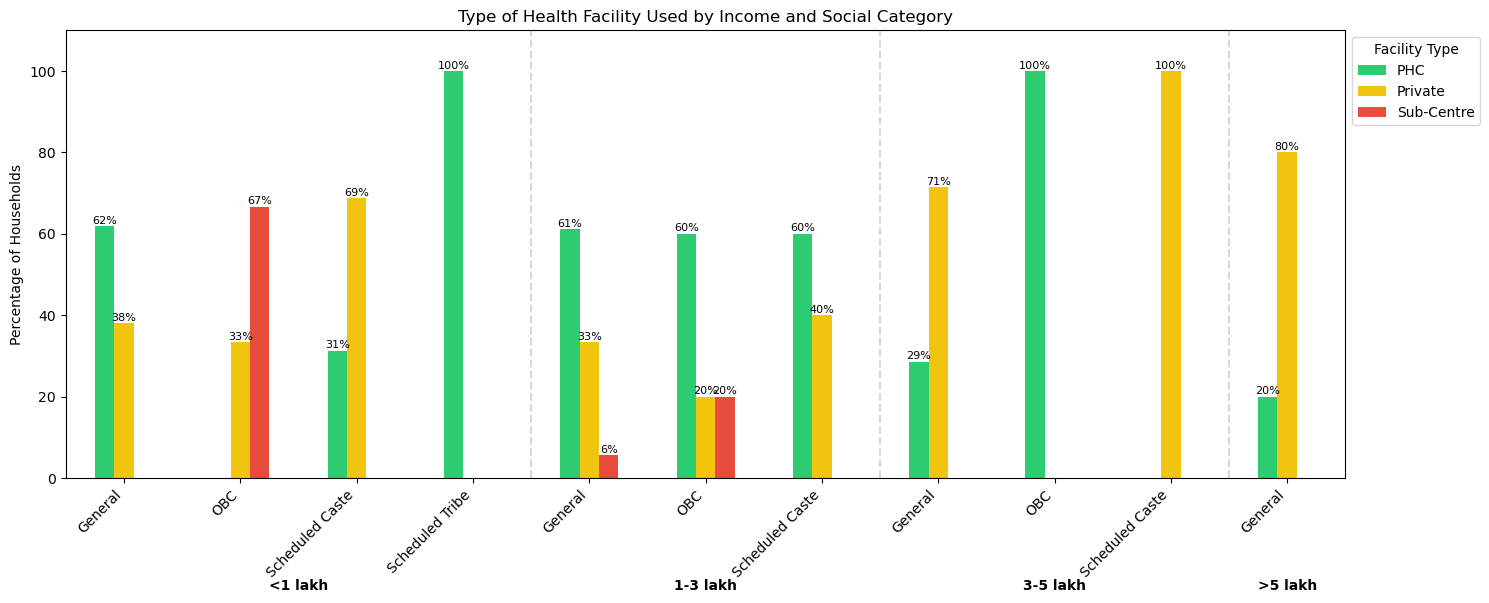

In [11]:
income_order = ['<1 lakh', '1-3 lakh', '3-5 lakh', '>5 lakh']
type_of_facility_used = type_of_facility_used.reindex(income_order, level=0)
health_plot = type_of_facility_used.copy()
health_plot.index = [i[1] for i in health_plot.index]
bars = health_plot.plot(kind='bar', figsize=(15,6), color=['#2ECC71','#F1C40F','#E74C3C'])

income_labels = [i[0] for i in type_of_facility_used.index]
positions = []
labels = []
prev = None

for idx, val in enumerate(income_labels):
    if val != prev:
        positions.append(idx)
        labels.append(val)
        prev = val

counts = pd.Series(income_labels).value_counts(sort=False).tolist()

current_pos = 0
for count, label in zip(counts, labels):
    center = current_pos + (count - 1) / 2
    plt.annotate(
        label,
        (center, -0.25),
        xycoords=('data','axes fraction'),
        ha='center',
        fontsize=10,
        fontweight='bold')
    current_pos += count

current_pos = 0
for count in counts[:-1]:
    current_pos += count
    plt.axvline(current_pos - 0.5, color='gray', linestyle='--', alpha=0.3)

for bar in bars.patches:
    if bar.get_height() > 0:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f"{bar.get_height():.0f}%",
            ha='center',
            va='bottom',
            fontsize=8)

plt.title("Type of Health Facility Used by Income and Social Category")
plt.ylabel("Percentage of Households")
plt.legend(title="Facility Type", bbox_to_anchor=(1,1), loc='upper left')
plt.ylim(0, 110)
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.show()

In [12]:
immunization_status_of_children = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], 
                                              df['Immunization status of children (0-5)'], normalize='index') * 100
round(immunization_status_of_children,2)

Immunization status of children (0-5)             Fully  Not immunised  \
Approx. Annual Household Income Social Category                          
1-3 lakh                        General           66.67          22.22   
                                OBC               80.00           0.00   
                                Scheduled Caste  100.00           0.00   
3-5 lakh                        General           71.43          28.57   
                                OBC              100.00           0.00   
                                Scheduled Caste   50.00          50.00   
<1 lakh                         General           66.67          23.81   
                                OBC                0.00          33.33   
                                Scheduled Caste   75.00          12.50   
                                Scheduled Tribe  100.00           0.00   
>5 lakh                         General           80.00          20.00   

Immunization status of children (0-5)            Partially  
Approx. Annual Household Income Social Category             
1-3 lakh                        General              11.11  
                                OBC                  20.00  
                                Scheduled Caste       0.00  
3-5 lakh                        General               0.00  
                                OBC                   0.00  
                                Scheduled Caste       0.00  
<1 lakh                         General               9.52  
                                OBC                  66.67  
                                Scheduled Caste      12.50  
                                Scheduled Tribe       0.00  
>5 lakh                         General               0.00

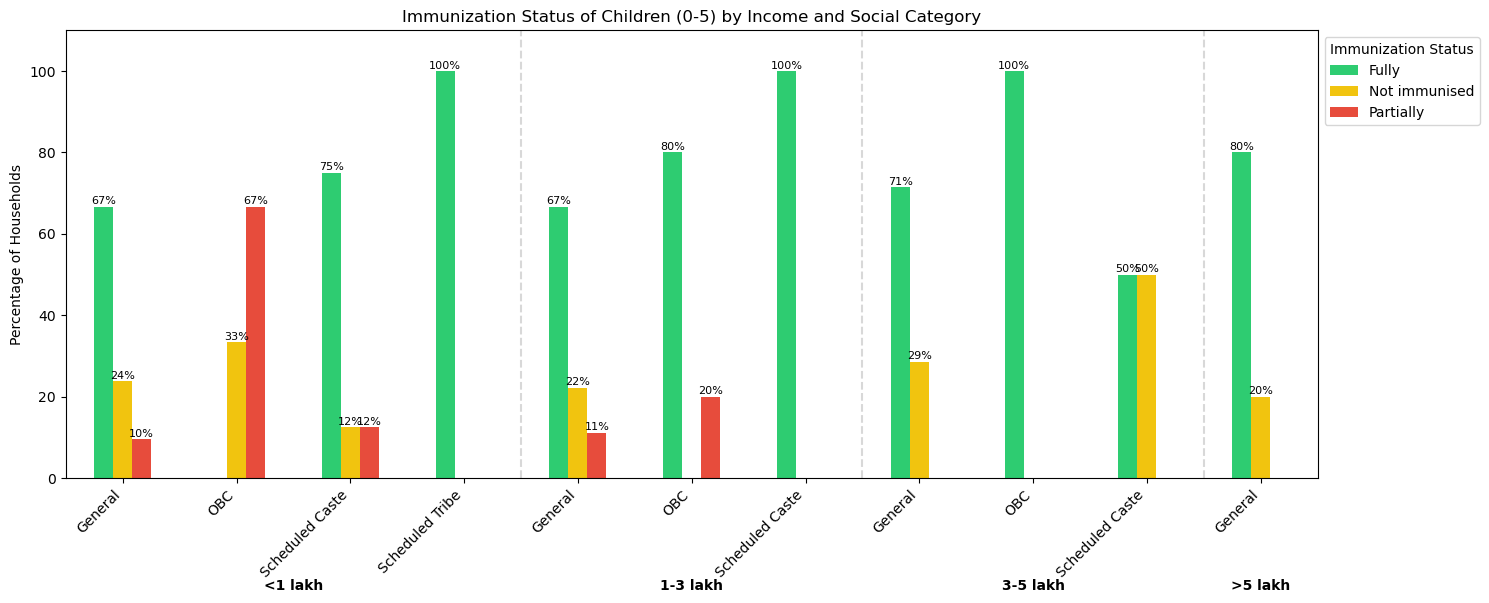

In [13]:
income_order = ['<1 lakh', '1-3 lakh', '3-5 lakh', '>5 lakh']
immunization_status_of_children = immunization_status_of_children.reindex(income_order, level=0)
health_plot = immunization_status_of_children.copy()
health_plot.index = [i[1] for i in health_plot.index]
bars = health_plot.plot(kind='bar', figsize=(15,6), color=['#2ECC71','#F1C40F','#E74C3C'])

income_labels = [i[0] for i in immunization_status_of_children.index]
positions = []
labels = []
prev = None
for idx, val in enumerate(income_labels):
    if val != prev:
        positions.append(idx)
        labels.append(val)
        prev = val

counts = pd.Series(income_labels).value_counts(sort=False).tolist()

current_pos = 0
for count, label in zip(counts, labels):
    center = current_pos + (count - 1) / 2
    plt.annotate(
        label,
        (center, -0.25),
        xycoords=('data','axes fraction'),
        ha='center',
        fontsize=10,
        fontweight='bold')
    current_pos += count

current_pos = 0
for count in counts[:-1]:
    current_pos += count
    plt.axvline(current_pos - 0.5, color='gray', linestyle='--', alpha=0.3)

for bar in bars.patches:
    if bar.get_height() > 0:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f"{bar.get_height():.0f}%",
            ha='center',
            va='bottom',
            fontsize=8)

plt.title("Immunization Status of Children (0-5) by Income and Social Category")
plt.ylabel("Percentage of Households")
plt.legend(title="Immunization Status", bbox_to_anchor=(1,1), loc='upper left')
plt.ylim(0, 110)
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.show()

In [14]:
pregnant_women_received_ANC_services = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], 
                                              df['Pregnant women received ANC services'], normalize='index') * 100
round(pregnant_women_received_ANC_services,2)

Pregnant women received ANC services                 No     Yes
Approx. Annual Household Income Social Category                
1-3 lakh                        General           63.64   36.36
                                OBC               75.00   25.00
                                Scheduled Caste   66.67   33.33
3-5 lakh                        General           40.00   60.00
                                OBC                0.00  100.00
                                Scheduled Caste   50.00   50.00
<1 lakh                         General           52.63   47.37
                                OBC              100.00    0.00
                                Scheduled Caste   36.36   63.64
                                Scheduled Tribe    0.00  100.00
>5 lakh                         General           66.67   33.33

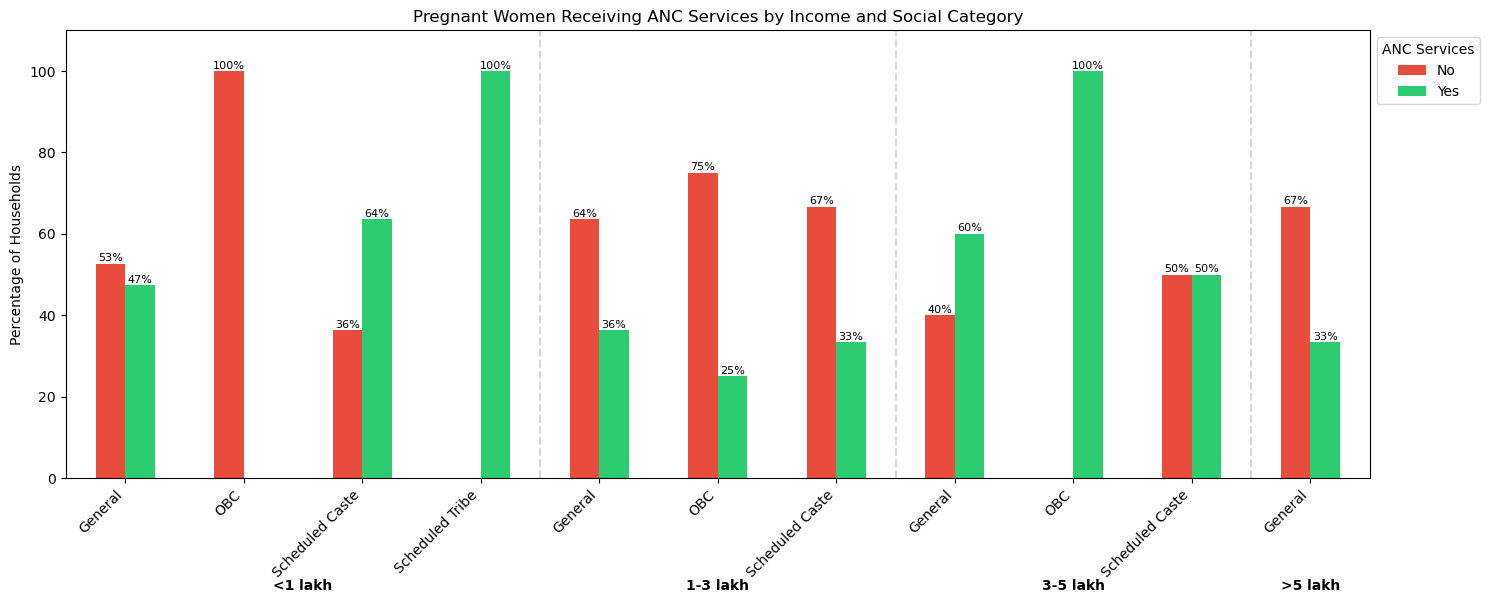

In [15]:
income_order = ['<1 lakh', '1-3 lakh', '3-5 lakh', '>5 lakh']
pregnant_women_received_ANC_services = pregnant_women_received_ANC_services.reindex(income_order, level=0)
health_plot = pregnant_women_received_ANC_services.copy()
health_plot.index = [i[1] for i in health_plot.index]
bars = health_plot.plot(kind='bar', figsize=(15,6), color=['#E74C3C', '#2ECC71'])
income_labels = [i[0] for i in pregnant_women_received_ANC_services.index]
positions = []
labels = []
prev = None
for idx, val in enumerate(income_labels):
    if val != prev:
        positions.append(idx)
        labels.append(val)
        prev = val

counts = pd.Series(income_labels).value_counts(sort=False).tolist()
current_pos = 0
for count, label in zip(counts, labels):
    center = current_pos + (count - 1) / 2
    plt.annotate(
        label,
        (center, -0.25),
        xycoords=('data','axes fraction'),
        ha='center',
        fontsize=10,
        fontweight='bold')
    current_pos += count

current_pos = 0
for count in counts[:-1]:
    current_pos += count
    plt.axvline(current_pos - 0.5, color='gray', linestyle='--', alpha=0.3)

for bar in bars.patches:
    if bar.get_height() > 0:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f"{bar.get_height():.0f}%",
            ha='center',
            va='bottom',
            fontsize=8)
plt.title("Pregnant Women Receiving ANC Services by Income and Social Category")
plt.ylabel("Percentage of Households")
plt.legend(title="ANC Services", bbox_to_anchor=(1,1), loc='upper left')
plt.ylim(0, 110)
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.show()

In [16]:
last_delivery_was_institutional = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], 
                                              df['Last delivery was institutional  (in any hospital)'], normalize='index') * 100
round(last_delivery_was_institutional,2)

Last delivery was institutional  (in any hospital)      No     YES
Approx. Annual Household Income Social Category                   
1-3 lakh                        General              55.56   44.44
                                OBC                  60.00   40.00
                                Scheduled Caste       0.00  100.00
3-5 lakh                        General              28.57   71.43
                                OBC                   0.00  100.00
                                Scheduled Caste      50.00   50.00
<1 lakh                         General              47.62   52.38
                                OBC                 100.00    0.00
                                Scheduled Caste      56.25   43.75
                                Scheduled Tribe     100.00    0.00
>5 lakh                         General              20.00   80.00

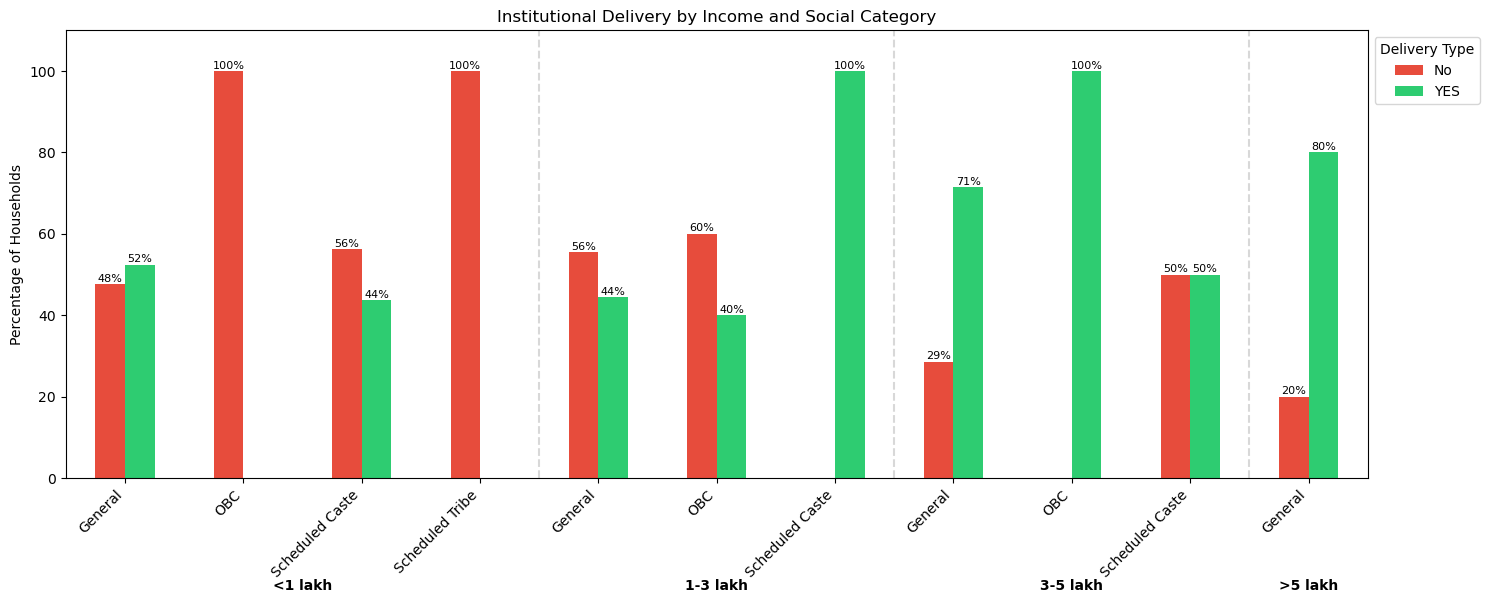

In [17]:
income_order = ['<1 lakh', '1-3 lakh', '3-5 lakh', '>5 lakh']
last_delivery_was_institutional = last_delivery_was_institutional.reindex(income_order, level=0)
health_plot = last_delivery_was_institutional.copy()
health_plot.index = [i[1] for i in health_plot.index]
bars = health_plot.plot(kind='bar',figsize=(15,6), color=['#E74C3C', '#2ECC71'])
income_labels = [i[0] for i in last_delivery_was_institutional.index]
positions = []
labels = []
prev = None
for idx, val in enumerate(income_labels):
    if val != prev:
        positions.append(idx)
        labels.append(val)
        prev = val

counts = pd.Series(income_labels).value_counts(sort=False).tolist()
current_pos = 0
for count, label in zip(counts, labels):
    center = current_pos + (count - 1) / 2
    plt.annotate(
        label,
        (center, -0.25),
        xycoords=('data','axes fraction'),
        ha='center',
        fontsize=10,
        fontweight='bold')
    current_pos += count

current_pos = 0
for count in counts[:-1]:
    current_pos += count
    plt.axvline(current_pos - 0.5, color='gray', linestyle='--', alpha=0.3)

for bar in bars.patches:
    if bar.get_height() > 0:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f"{bar.get_height():.0f}%",
            ha='center',
            va='bottom',
            fontsize=8)

plt.title("Institutional Delivery by Income and Social Category")
plt.ylabel("Percentage of Households")
plt.legend(title="Delivery Type", bbox_to_anchor=(1,1), loc='upper left')
plt.ylim(0, 110)
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.show()

In [18]:
toilet_availability = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], 
                                              df['Toilet availability'], normalize='index') * 100
round(toilet_availability,2)

Toilet availability                                 NO    YES
Approx. Annual Household Income Social Category              
1-3 lakh                        General            0.0  100.0
                                OBC                0.0  100.0
                                Scheduled Caste    0.0  100.0
3-5 lakh                        General            0.0  100.0
                                OBC                0.0  100.0
                                Scheduled Caste    0.0  100.0
<1 lakh                         General            0.0  100.0
                                OBC                0.0  100.0
                                Scheduled Caste    0.0  100.0
                                Scheduled Tribe  100.0    0.0
>5 lakh                         General            0.0  100.0

In [19]:
handwashing_with_soap = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], 
                                              df['Handwashing with soap'], normalize='index') * 100
round(handwashing_with_soap,2)

Handwashing with soap                            Always  Rarely  Sometimes
Approx. Annual Household Income Social Category                           
1-3 lakh                        General          100.00    0.00       0.00
                                OBC              100.00    0.00       0.00
                                Scheduled Caste  100.00    0.00       0.00
3-5 lakh                        General          100.00    0.00       0.00
                                OBC              100.00    0.00       0.00
                                Scheduled Caste  100.00    0.00       0.00
<1 lakh                         General          100.00    0.00       0.00
                                OBC               33.33    0.00      66.67
                                Scheduled Caste   93.75    6.25       0.00
                                Scheduled Tribe  100.00    0.00       0.00
>5 lakh                         General          100.00    0.00       0.00

In [20]:
health_schemes_ayushman_bharat = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], 
                                              df['Health Schemes   [Ayushman Bharat (PM-JAY)]'], normalize='index') * 100
round(health_schemes_ayushman_bharat,2)

Health Schemes   [Ayushman Bharat (PM-JAY)]      Applied  Availed   Aware  \
Approx. Annual Household Income Social Category                             
1-3 lakh                        General             0.00    33.33   27.78   
                                OBC                40.00     0.00   20.00   
                                Scheduled Caste     0.00    20.00    0.00   
3-5 lakh                        General             0.00    14.29   42.86   
                                OBC                 0.00     0.00  100.00   
                                Scheduled Caste     0.00     0.00   50.00   
<1 lakh                         General            28.57    28.57   28.57   
                                OBC                 0.00    33.33    0.00   
                                Scheduled Caste    18.75     6.25   43.75   
                                Scheduled Tribe     0.00     0.00  100.00   
>5 lakh                         General             0.00    20.00   60.00   

Health Schemes   [Ayushman Bharat (PM-JAY)]      Not aware  
Approx. Annual Household Income Social Category             
1-3 lakh                        General              38.89  
                                OBC                  40.00  
                                Scheduled Caste      80.00  
3-5 lakh                        General              42.86  
                                OBC                   0.00  
                                Scheduled Caste      50.00  
<1 lakh                         General              14.29  
                                OBC                  66.67  
                                Scheduled Caste      31.25  
                                Scheduled Tribe       0.00  
>5 lakh                         General              20.00

In [21]:
health_schemes_Janani_Suraksha = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], 
                                              df['Health Schemes   [Janani Suraksha Yojana]'], normalize='index') * 100
round(health_schemes_Janani_Suraksha,2)

Health Schemes   [Janani Suraksha Yojana]        Availed   Aware  Not aware
Approx. Annual Household Income Social Category                            
1-3 lakh                        General             0.00   27.78      72.22
                                OBC                 0.00   20.00      80.00
                                Scheduled Caste     0.00    0.00     100.00
3-5 lakh                        General             0.00   42.86      57.14
                                OBC                 0.00  100.00       0.00
                                Scheduled Caste     0.00    0.00     100.00
<1 lakh                         General             9.52   47.62      42.86
                                OBC                 0.00    0.00     100.00
                                Scheduled Caste    12.50   25.00      62.50
                                Scheduled Tribe     0.00  100.00       0.00
>5 lakh                         General             0.00   40.00      60.00

In [22]:
health_schemes_Janani_Shishu_Suraksha_Karyakram = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], 
                                              df['Health Schemes   [Janani Shishu Suraksha Karyakram]'], normalize='index') * 100
round(health_schemes_Janani_Shishu_Suraksha_Karyakram,2)

Health Schemes   [Janani Shishu Suraksha Karyakram]  Applied  Availed   Aware  \
Approx. Annual Household Income Social Category                                 
1-3 lakh                        General                 5.56     0.00   22.22   
                                OBC                     0.00     0.00   20.00   
                                Scheduled Caste         0.00     0.00    0.00   
3-5 lakh                        General                 0.00     0.00   42.86   
                                OBC                     0.00     0.00  100.00   
                                Scheduled Caste         0.00     0.00    0.00   
<1 lakh                         General                 0.00     9.52   42.86   
                                OBC                     0.00     0.00    0.00   
                                Scheduled Caste         6.25     6.25   25.00   
                                Scheduled Tribe         0.00     0.00  100.00   
>5 lakh                         General                 0.00     0.00   40.00   

Health Schemes   [Janani Shishu Suraksha Karyakram]  Not aware  
Approx. Annual Household Income Social Category                 
1-3 lakh                        General                  72.22  
                                OBC                      80.00  
                                Scheduled Caste         100.00  
3-5 lakh                        General                  57.14  
                                OBC                       0.00  
                                Scheduled Caste         100.00  
<1 lakh                         General                  47.62  
                                OBC                     100.00  
                                Scheduled Caste          62.50  
                                Scheduled Tribe           0.00  
>5 lakh                         General                  60.00

In [23]:
health_schemes_Poshan_Abhiyaan = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], 
                                              df['Health Schemes   [Poshan Abhiyaan / ICDS]'], normalize='index') * 100
round(health_schemes_Poshan_Abhiyaan,2)

Health Schemes   [Poshan Abhiyaan / ICDS]        Applied  Availed   Aware  \
Approx. Annual Household Income Social Category                             
1-3 lakh                        General             0.00     5.56   27.78   
                                OBC                 0.00     0.00   20.00   
                                Scheduled Caste     0.00     0.00    0.00   
3-5 lakh                        General             0.00     0.00   28.57   
                                OBC                 0.00     0.00  100.00   
                                Scheduled Caste     0.00     0.00   50.00   
<1 lakh                         General             4.76     9.52   42.86   
                                OBC                 0.00     0.00    0.00   
                                Scheduled Caste     0.00     0.00   43.75   
                                Scheduled Tribe     0.00     0.00  100.00   
>5 lakh                         General             0.00     0.00   40.00   

Health Schemes   [Poshan Abhiyaan / ICDS]        Not aware  
Approx. Annual Household Income Social Category             
1-3 lakh                        General              66.67  
                                OBC                  80.00  
                                Scheduled Caste     100.00  
3-5 lakh                        General              71.43  
                                OBC                   0.00  
                                Scheduled Caste      50.00  
<1 lakh                         General              42.86  
                                OBC                 100.00  
                                Scheduled Caste      56.25  
                                Scheduled Tribe       0.00  
>5 lakh                         General              60.00

# Education Gap Analysis

In [24]:
income_order = ['<1 lakh', '1-3 lakh', '3-5 lakh', '>5 lakh']
df['Approx. Annual Household Income'] = pd.Categorical(df['Approx. Annual Household Income'], categories=income_order, ordered=True)

In [25]:
income_dropout = pd.crosstab([df['Approx. Annual Household Income'],df['Social Category']], df['School dropout cases  in the household'], 
                             normalize='index') * 100
round(income_dropout,2)

School dropout cases  in the household               NO  Partia    YES
Approx. Annual Household Income Social Category                       
<1 lakh                         General           80.95    0.00  19.05
                                OBC               66.67   33.33   0.00
                                Scheduled Caste   68.75    0.00  31.25
                                Scheduled Tribe  100.00    0.00   0.00
1-3 lakh                        General           77.78    5.56  16.67
                                OBC              100.00    0.00   0.00
                                Scheduled Caste   80.00    0.00  20.00
3-5 lakh                        General          100.00    0.00   0.00
                                OBC              100.00    0.00   0.00
                                Scheduled Caste  100.00    0.00   0.00
>5 lakh                         General          100.00    0.00   0.00

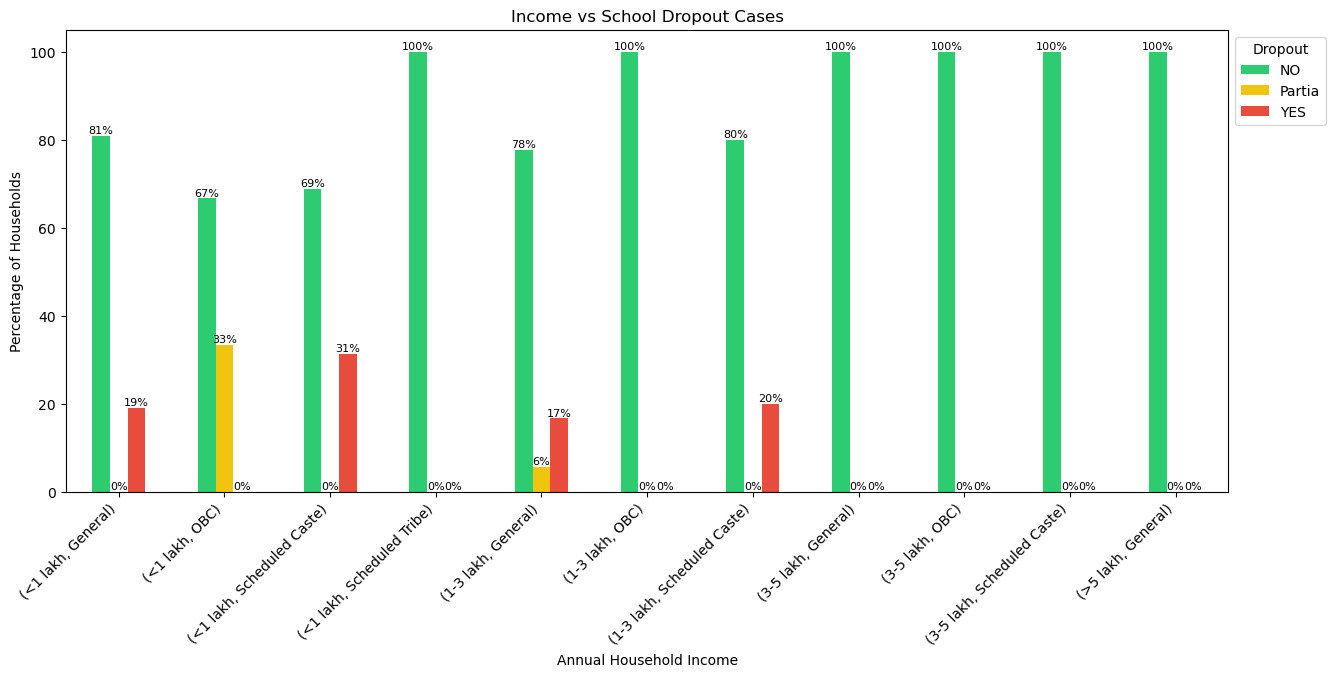

In [26]:
bars = income_dropout.plot(kind='bar', figsize=(15,6), color=['#2ECC71','#F1C40F','#E74C3C'])
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()+0.1,
             f"{bar.get_height():.0f}%",
             ha='center',
             va='bottom',
             fontsize=8)
plt.title("Income vs School Dropout Cases")
plt.ylabel("Percentage of Households")
plt.xlabel("Annual Household Income")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Dropout", bbox_to_anchor=(1,1), loc='upper left')
plt.show()

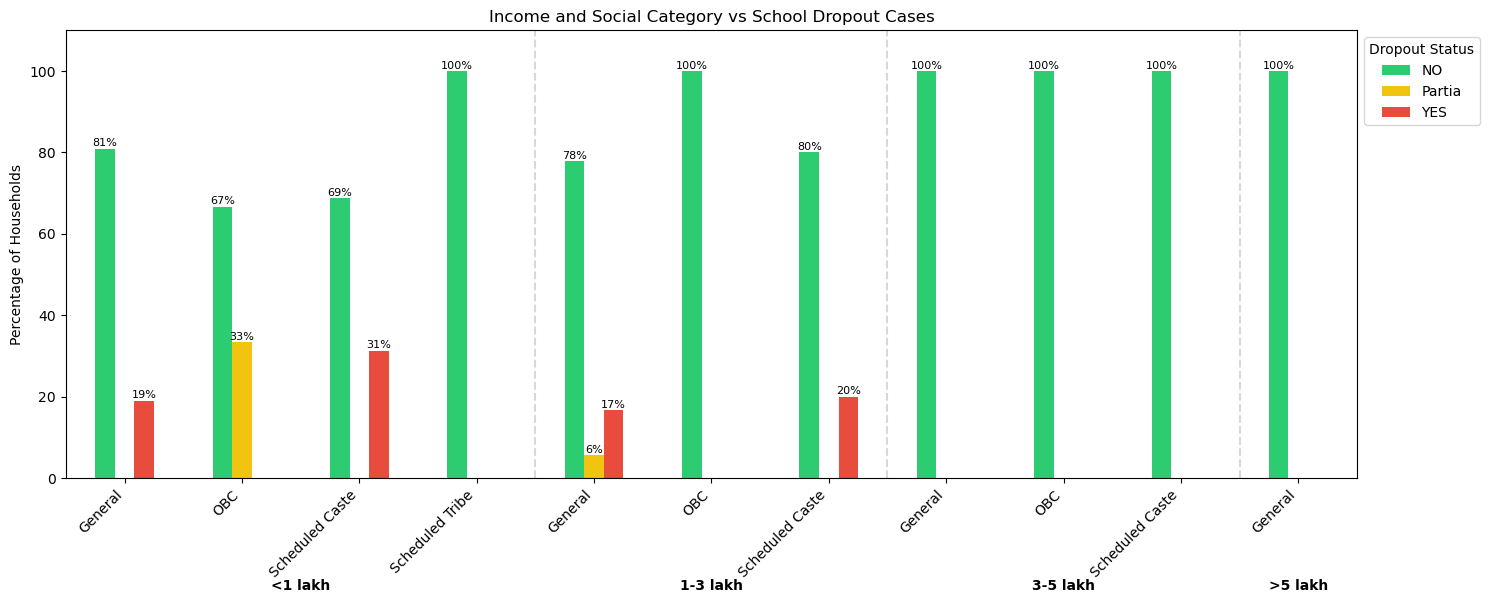

In [27]:
health_plot = income_dropout.copy()
health_plot.index = [i[1] for i in health_plot.index]
bars = health_plot.plot(kind='bar', figsize=(15,6),color=['#2ECC71', '#F1C40F', '#E74C3C'])

income_labels = [i[0] for i in income_dropout.index]
positions = []
labels = []
prev = None
for idx, val in enumerate(income_labels):
    if val != prev:
        positions.append(idx)
        labels.append(val)
        prev = val

counts = pd.Series(income_labels).value_counts(sort=False).tolist()
current_pos = 0
for count, label in zip(counts, labels):
    center = current_pos + (count - 1) / 2
    plt.annotate(
        label,
        (center, -0.25),
        xycoords=('data','axes fraction'),
        ha='center',
        fontsize=10,
        fontweight='bold')
    current_pos += count

current_pos = 0
for count in counts[:-1]:
    current_pos += count
    plt.axvline(current_pos - 0.5, color='gray', linestyle='--', alpha=0.3)

for bar in bars.patches:
    if bar.get_height() > 0:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f"{bar.get_height():.0f}%",
            ha='center',
            va='bottom',
            fontsize=8)

plt.title("Income and Social Category vs School Dropout Cases")
plt.ylabel("Percentage of Households")
plt.legend(title="Dropout Status", bbox_to_anchor=(1,1), loc='upper left') 
plt.ylim(0, 110)
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.show()

In [28]:
children_enrolled_in_school = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], 
                                              df['Children enrolled in school'], normalize='index') * 100
round(children_enrolled_in_school,2)

Children enrolled in school                         No     Yes
Approx. Annual Household Income Social Category               
<1 lakh                         General          28.57   71.43
                                OBC               0.00  100.00
                                Scheduled Caste  18.75   81.25
                                Scheduled Tribe   0.00  100.00
1-3 lakh                        General          27.78   72.22
                                OBC              40.00   60.00
                                Scheduled Caste   0.00  100.00
3-5 lakh                        General          28.57   71.43
                                OBC               0.00  100.00
                                Scheduled Caste  50.00   50.00
>5 lakh                         General           0.00  100.00

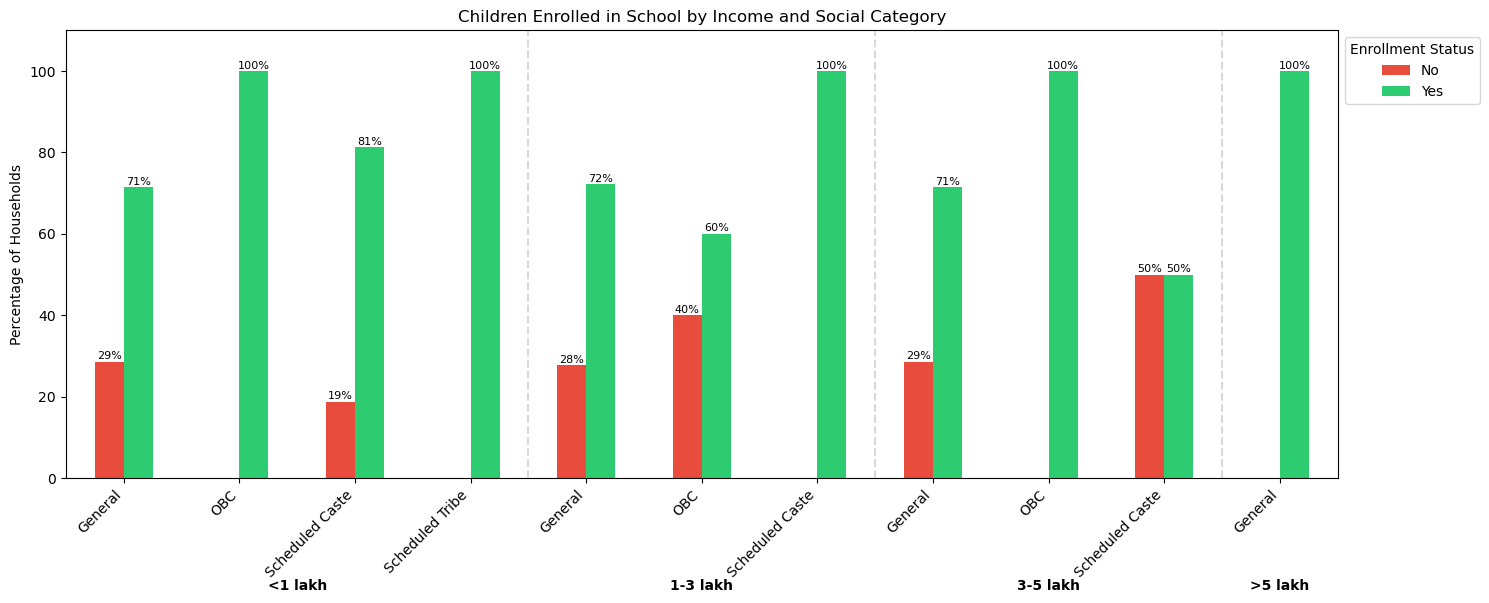

In [29]:
health_plot = children_enrolled_in_school.copy()
health_plot.index = [i[1] for i in health_plot.index]
bars = health_plot.plot(kind='bar', figsize=(15,6), color=['#E74C3C', '#2ECC71'])
income_labels = [i[0] for i in children_enrolled_in_school.index]
positions = []
labels = []
prev = None
for idx, val in enumerate(income_labels):
    if val != prev:
        positions.append(idx)
        labels.append(val)
        prev = val

counts = pd.Series(income_labels).value_counts(sort=False).tolist()
current_pos = 0
for count, label in zip(counts, labels):
    center = current_pos + (count - 1) / 2
    plt.annotate(
        label,
        (center, -0.25),
        xycoords=('data','axes fraction'),
        ha='center',
        fontsize=10,
        fontweight='bold')
    current_pos += count
current_pos = 0

for count in counts[:-1]:
    current_pos += count
    plt.axvline(current_pos - 0.5, color='gray', linestyle='--', alpha=0.3)

for bar in bars.patches:
    if bar.get_height() > 0:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f"{bar.get_height():.0f}%",
            ha='center',
            va='bottom',
            fontsize=8)
plt.title("Children Enrolled in School by Income and Social Category")
plt.ylabel("Percentage of Households")
plt.legend(title="Enrollment Status", bbox_to_anchor=(1,1), loc='upper left')
plt.ylim(0, 110)
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.show()

In [30]:
literacy_status_of_household = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], 
                                              df['Literacy status of household'], normalize='index') * 100
round(literacy_status_of_household,2)

Literacy status of household                     All literate  \
Approx. Annual Household Income Social Category                 
<1 lakh                         General                 38.10   
                                OBC                     33.33   
                                Scheduled Caste         25.00   
                                Scheduled Tribe          0.00   
1-3 lakh                        General                 33.33   
                                OBC                     60.00   
                                Scheduled Caste          0.00   
3-5 lakh                        General                 85.71   
                                OBC                    100.00   
                                Scheduled Caste        100.00   
>5 lakh                         General                 80.00   

Literacy status of household                     Mostly illiterate  \
Approx. Annual Household Income Social Category                      
<1 lakh                         General                       4.76   
                                OBC                           0.00   
                                Scheduled Caste               6.25   
                                Scheduled Tribe               0.00   
1-3 lakh                        General                       0.00   
                                OBC                           0.00   
                                Scheduled Caste              40.00   
3-5 lakh                        General                       0.00   
                                OBC                           0.00   
                                Scheduled Caste               0.00   
>5 lakh                         General                      20.00   

Literacy status of household                     Partially literate  
Approx. Annual Household Income Social Category                      
<1 lakh                         General                       57.14  
                                OBC                           66.67  
                                Scheduled Caste               68.75  
                                Scheduled Tribe              100.00  
1-3 lakh                        General                       66.67  
                                OBC                           40.00  
                                Scheduled Caste               60.00  
3-5 lakh                        General                       14.29  
                                OBC                            0.00  
                                Scheduled Caste                0.00  
>5 lakh                         General                        0.00

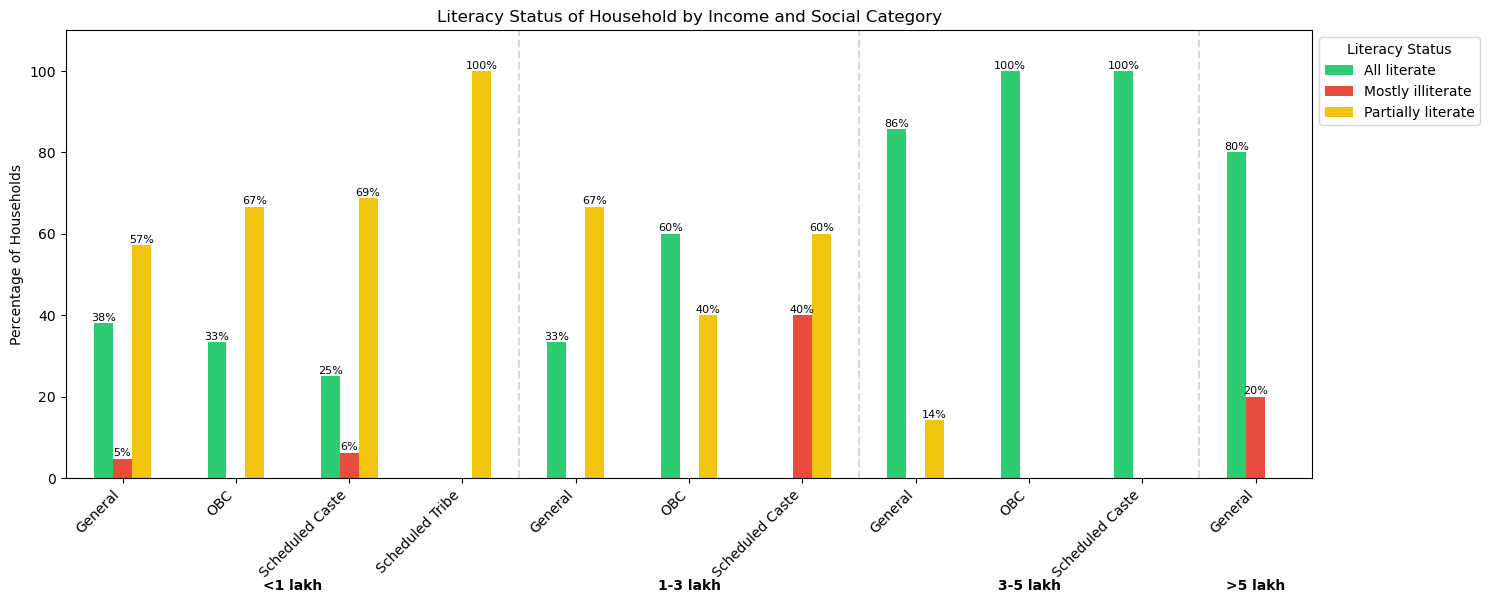

In [31]:
health_plot = literacy_status_of_household.copy()
health_plot.index = [i[1] for i in health_plot.index]
bars = health_plot.plot(kind='bar', figsize=(15,6), color=['#2ECC71', '#E74C3C', '#F1C40F'])
income_labels = [i[0] for i in literacy_status_of_household.index]

positions = []
labels = []
prev = None
for idx, val in enumerate(income_labels):
    if val != prev:
        positions.append(idx)
        labels.append(val)
        prev = val

counts = pd.Series(income_labels).value_counts(sort=False).tolist()
current_pos = 0
for count, label in zip(counts, labels):
    center = current_pos + (count - 1) / 2
    plt.annotate(
        label,
        (center, -0.25),
        xycoords=('data','axes fraction'),
        ha='center',
        fontsize=10,
        fontweight='bold')
    current_pos += count

current_pos = 0
for count in counts[:-1]:
    current_pos += count
    plt.axvline(current_pos - 0.5, color='gray', linestyle='--', alpha=0.3)

for bar in bars.patches:
    if bar.get_height() > 0:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f"{bar.get_height():.0f}%",
            ha='center',
            va='bottom',
            fontsize=8)

plt.title("Literacy Status of Household by Income and Social Category")
plt.ylabel("Percentage of Households")
plt.legend(title="Literacy Status", bbox_to_anchor=(1,1), loc='upper left')
plt.ylim(0, 110)
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.show()

In [32]:
type_of_school = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], 
                                              df['Type of school'], normalize='index') * 100
round(type_of_school,2)

Type of school                                   Government  Private
Approx. Annual Household Income Social Category                     
<1 lakh                         General                50.0     50.0
                                OBC                   100.0      0.0
                                Scheduled Caste       100.0      0.0
                                Scheduled Tribe       100.0      0.0
1-3 lakh                        General                62.5     37.5
                                OBC                    75.0     25.0
                                Scheduled Caste       100.0      0.0
3-5 lakh                        General                 0.0    100.0
                                OBC                   100.0      0.0
                                Scheduled Caste       100.0      0.0
>5 lakh                         General                20.0     80.0

In [33]:
distance_to_nearest_school = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], 
                                              df['Distance to nearest school'], normalize='index') * 100
round(distance_to_nearest_school,2)

Distance to nearest school                       1-3 km   <1 km  >3 km
Approx. Annual Household Income Social Category                       
<1 lakh                         General           28.57   42.86  28.57
                                OBC               33.33   33.33  33.33
                                Scheduled Caste   43.75   50.00   6.25
                                Scheduled Tribe    0.00  100.00   0.00
1-3 lakh                        General           55.56   33.33  11.11
                                OBC               20.00   80.00   0.00
                                Scheduled Caste   20.00   40.00  40.00
3-5 lakh                        General           42.86    0.00  57.14
                                OBC              100.00    0.00   0.00
                                Scheduled Caste   50.00   50.00   0.00
>5 lakh                         General            0.00   40.00  60.00

In [34]:
df['Reason for dropout'].value_counts()

Reason for dropout
Financial           26
Migration           18
Lack of interest    12
Domestic work        6
Name: count, dtype: int64

In [35]:
reason_for_dropout = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], 
                                              df['Reason for dropout'], normalize='index') * 100
round(reason_for_dropout,2)

Reason for dropout                               Domestic work  Financial  \
Approx. Annual Household Income Social Category                             
<1 lakh                         General                   0.00      62.50   
                                OBC                       0.00       0.00   
                                Scheduled Caste           8.33      41.67   
1-3 lakh                        General                  20.00      26.67   
                                OBC                      20.00      20.00   
                                Scheduled Caste           0.00     100.00   
3-5 lakh                        General                   0.00       0.00   
                                OBC                     100.00       0.00   
                                Scheduled Caste           0.00      50.00   
>5 lakh                         General                   0.00     100.00   

Reason for dropout                               Lack of interest  Migration  
Approx. Annual Household Income Social Category                               
<1 lakh                         General                     18.75      18.75  
                                OBC                         33.33      66.67  
                                Scheduled Caste              0.00      50.00  
1-3 lakh                        General                     40.00      13.33  
                                OBC                         40.00      20.00  
                                Scheduled Caste              0.00       0.00  
3-5 lakh                        General                      0.00     100.00  
                                OBC                          0.00       0.00  
                                Scheduled Caste              0.00      50.00  
>5 lakh                         General                      0.00       0.00

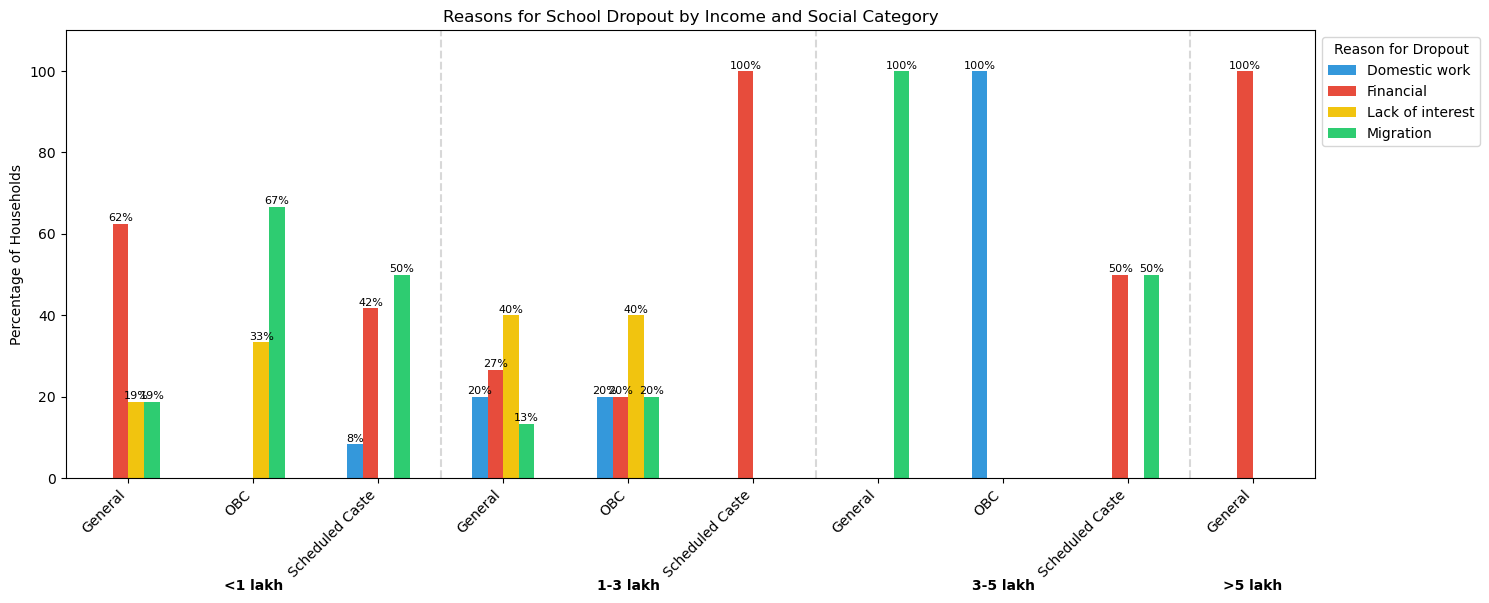

In [36]:
# Define income order
income_order = ['<1 lakh', '1-3 lakh', '3-5 lakh', '>5 lakh']

# Sort dataset
reason_for_dropout = reason_for_dropout.reindex(income_order, level=0)

# Use correct dataset
health_plot = reason_for_dropout.copy()
health_plot.index = [i[1] for i in health_plot.index]

bars = health_plot.plot(
    kind='bar',
    figsize=(15,6),
    color=['#3498DB', '#E74C3C', '#F1C40F', '#2ECC71']  # Domestic, Financial, Interest, Migration
)

# Extract income labels
income_labels = [i[0] for i in reason_for_dropout.index]

positions = []
labels = []
prev = None

for idx, val in enumerate(income_labels):
    if val != prev:
        positions.append(idx)
        labels.append(val)
        prev = val

# Group sizes
counts = pd.Series(income_labels).value_counts(sort=False).tolist()

# Add income group labels
current_pos = 0
for count, label in zip(counts, labels):
    center = current_pos + (count - 1) / 2
    plt.annotate(
        label,
        (center, -0.25),
        xycoords=('data','axes fraction'),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )
    current_pos += count

# Add separators
current_pos = 0
for count in counts[:-1]:
    current_pos += count
    plt.axvline(current_pos - 0.5, color='gray', linestyle='--', alpha=0.3)

# Add percentage labels
for bar in bars.patches:
    if bar.get_height() > 0:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f"{bar.get_height():.0f}%",
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.title("Reasons for School Dropout by Income and Social Category")
plt.ylabel("Percentage of Households")
plt.legend(title="Reason for Dropout", bbox_to_anchor=(1,1), loc='upper left')
plt.ylim(0, 110)
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.show()

In [37]:
access_to_digital_devices = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], 
                                              df['Access to digital devices'], normalize='index') * 100
round(access_to_digital_devices,2)

Access to digital devices                        Laptop  Smartphone  \
Approx. Annual Household Income Social Category                       
<1 lakh                         General            0.00       95.24   
                                OBC                0.00      100.00   
                                Scheduled Caste    0.00       93.75   
1-3 lakh                        General            6.67       86.67   
                                OBC                0.00      100.00   
                                Scheduled Caste    0.00      100.00   
3-5 lakh                        General            0.00       71.43   
                                OBC                0.00      100.00   
                                Scheduled Caste    0.00       50.00   
>5 lakh                         General           20.00       20.00   

Access to digital devices                        Smartphone, Laptop  
Approx. Annual Household Income Social Category                      
<1 lakh                         General                        4.76  
                                OBC                            0.00  
                                Scheduled Caste                6.25  
1-3 lakh                        General                        6.67  
                                OBC                            0.00  
                                Scheduled Caste                0.00  
3-5 lakh                        General                       28.57  
                                OBC                            0.00  
                                Scheduled Caste               50.00  
>5 lakh                         General                       60.00

In [38]:
girls_continuing_education_beyond_Class_X = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], 
                                              df['Girls continuing education beyond Class X'], normalize='index') * 100
round(girls_continuing_education_beyond_Class_X,2)

Girls continuing education beyond Class X           No     YES
Approx. Annual Household Income Social Category               
<1 lakh                         General          47.62   52.38
                                OBC               0.00  100.00
                                Scheduled Caste  43.75   56.25
                                Scheduled Tribe   0.00  100.00
1-3 lakh                        General          38.89   61.11
                                OBC              40.00   60.00
                                Scheduled Caste  20.00   80.00
3-5 lakh                        General          14.29   85.71
                                OBC               0.00  100.00
                                Scheduled Caste  50.00   50.00
>5 lakh                         General          20.00   80.00

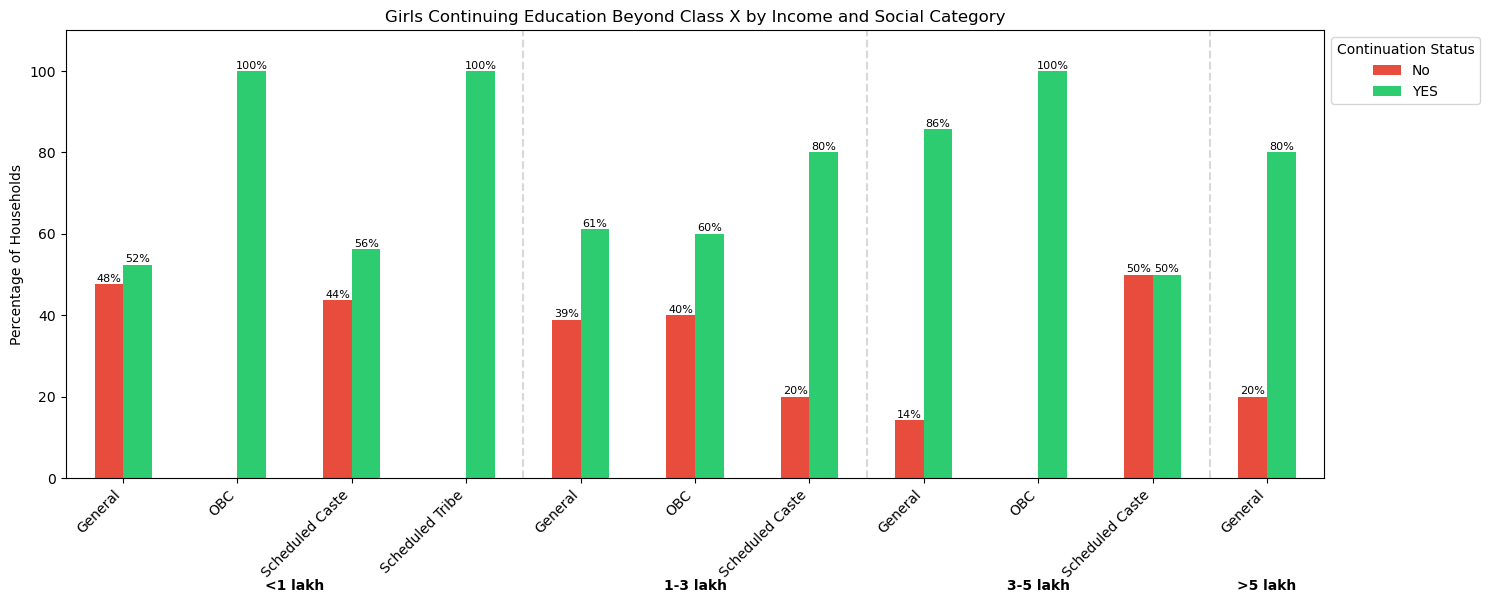

In [39]:
health_plot = girls_continuing_education_beyond_Class_X.copy()
health_plot.index = [i[1] for i in health_plot.index]
bars = health_plot.plot(kind='bar', figsize=(15,6), color=['#E74C3C', '#2ECC71'])
    
income_labels = [i[0] for i in girls_continuing_education_beyond_Class_X.index]
positions = []
labels = []
prev = None
for idx, val in enumerate(income_labels):
    if val != prev:
        positions.append(idx)
        labels.append(val)
        prev = val

counts = pd.Series(income_labels).value_counts(sort=False).tolist()
current_pos = 0
for count, label in zip(counts, labels):
    center = current_pos + (count - 1) / 2
    plt.annotate(
        label,
        (center, -0.25),
        xycoords=('data','axes fraction'),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )
    current_pos += count

current_pos = 0
for count in counts[:-1]:
    current_pos += count
    plt.axvline(current_pos - 0.5, color='gray', linestyle='--', alpha=0.3)

for bar in bars.patches:
    if bar.get_height() > 0:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f"{bar.get_height():.0f}%",
            ha='center',
            va='bottom',
            fontsize=8)

plt.title("Girls Continuing Education Beyond Class X by Income and Social Category")
plt.ylabel("Percentage of Households")
plt.legend(title="Continuation Status", bbox_to_anchor=(1,1), loc='upper left')
plt.ylim(0, 110)
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.show()

In [40]:
need_for_remedial_coaching_support = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], 
                                              df['Need for remedial/coaching support'], normalize='index') * 100
round(need_for_remedial_coaching_support,2)

Need for remedial/coaching support                   No     Yes
Approx. Annual Household Income Social Category                
<1 lakh                         General           76.19   23.81
                                OBC                0.00  100.00
                                Scheduled Caste   18.75   81.25
                                Scheduled Tribe    0.00  100.00
1-3 lakh                        General           61.11   38.89
                                OBC               60.00   40.00
                                Scheduled Caste   60.00   40.00
3-5 lakh                        General           85.71   14.29
                                OBC              100.00    0.00
                                Scheduled Caste    0.00  100.00
>5 lakh                         General           80.00   20.00

# Environmental Inequality

In [41]:
source_of_drinking_water = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], 
                                       df['Source of drinking water'], normalize='index') * 100
round(source_of_drinking_water,2)

Source of drinking water                         Hand pump  Hand pump, Well  \
Approx. Annual Household Income Social Category                               
<1 lakh                         General               4.76             0.00   
                                OBC                   0.00             0.00   
                                Scheduled Caste       0.00             0.00   
                                Scheduled Tribe       0.00             0.00   
1-3 lakh                        General               0.00             0.00   
                                OBC                   0.00             0.00   
                                Scheduled Caste       0.00             0.00   
3-5 lakh                        General               0.00            14.29   
                                OBC                   0.00             0.00   
                                Scheduled Caste       0.00             0.00   
>5 lakh                         General               0.00             0.00   

Source of drinking water                         Tanker     Tap  \
Approx. Annual Household Income Social Category                   
<1 lakh                         General            0.00   76.19   
                                OBC                0.00   33.33   
                                Scheduled Caste    0.00   87.50   
                                Scheduled Tribe    0.00  100.00   
1-3 lakh                        General            5.56   83.33   
                                OBC                0.00   80.00   
                                Scheduled Caste   20.00   80.00   
3-5 lakh                        General            0.00   71.43   
                                OBC                0.00  100.00   
                                Scheduled Caste    0.00   50.00   
>5 lakh                         General            0.00   80.00   

Source of drinking water                         Tap, Hand pump  Tap, Tanker  \
Approx. Annual Household Income Social Category                                
<1 lakh                         General                    0.00        14.29   
                                OBC                        0.00        66.67   
                                Scheduled Caste            6.25         0.00   
                                Scheduled Tribe            0.00         0.00   
1-3 lakh                        General                    5.56         5.56   
                                OBC                        0.00         0.00   
                                Scheduled Caste            0.00         0.00   
3-5 lakh                        General                   14.29         0.00   
                                OBC                        0.00         0.00   
                                Scheduled Caste           50.00         0.00   
>5 lakh                         General                    0.00        20.00   

Source of drinking water                         Tap, Well  Well  
Approx. Annual Household Income Social Category                   
<1 lakh                         General               0.00  4.76  
                                OBC                   0.00  0.00  
                                Scheduled Caste       6.25  0.00  
                                Scheduled Tribe       0.00  0.00  
1-3 lakh                        General               0.00  0.00  
                                OBC                  20.00  0.00  
                                Scheduled Caste       0.00  0.00  
3-5 lakh                        General               0.00  0.00  
                                OBC                   0.00  0.00  
                                Scheduled Caste       0.00  0.00  
>5 lakh                         General               0.00  0.00

In [42]:
def categorize_water(source):
    source = str(source)
    if 'Tap' in source:
        return 'Tap'
    elif 'Hand pump' in source:
        return 'Hand Pump'
    elif 'Tanker' in source:
        return 'Tanker'
    elif 'Pond' in source:
        return 'Pond'
    elif 'Well' in source:
        return 'Well'
    else:
        return 'Other'

df['Water Source'] = df['Source of drinking water'].apply(categorize_water)

In [43]:
water_clean = pd.crosstab([df['Approx. Annual Household Income'], df['Social Category']], df['Water Source'], normalize='index') * 100
round(water_clean, 2)

Water Source                                     Hand Pump  Tanker     Tap  \
Approx. Annual Household Income Social Category                              
<1 lakh                         General               4.76    0.00   90.48   
                                OBC                   0.00    0.00  100.00   
                                Scheduled Caste       0.00    0.00  100.00   
                                Scheduled Tribe       0.00    0.00  100.00   
1-3 lakh                        General               0.00    5.56   94.44   
                                OBC                   0.00    0.00  100.00   
                                Scheduled Caste       0.00   20.00   80.00   
3-5 lakh                        General              14.29    0.00   85.71   
                                OBC                   0.00    0.00  100.00   
                                Scheduled Caste       0.00    0.00  100.00   
>5 lakh                         General               0.00    0.00  100.00   

Water Source                                     Well  
Approx. Annual Household Income Social Category        
<1 lakh                         General          4.76  
                                OBC              0.00  
                                Scheduled Caste  0.00  
                                Scheduled Tribe  0.00  
1-3 lakh                        General          0.00  
                                OBC              0.00  
                                Scheduled Caste  0.00  
3-5 lakh                        General          0.00  
                                OBC              0.00  
                                Scheduled Caste  0.00  
>5 lakh                         General          0.00

In [44]:
x = df['Source of drinking water'].str.split(',').explode().str.strip()

In [45]:
x.value_counts()

Source of drinking water
Tap          79
Tanker        9
Hand pump     6
Well          4
Name: count, dtype: int64